# 0. Cargar datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## 0.1. Ventas

In [2]:
# Cargar datos
path_ventas = "datos/Ventas por Cliente/preliminar_ventas_con_precio_lista_2025_2026.csv"
ventas = pd.read_csv(path_ventas)
print("Ventas - Filas:", ventas.shape[0])
ventas.head()

Ventas - Filas: 10596574


,Año,Mes,Cod Canal Comercial,Clase Factura,Fecha Factura,Cod Cliente,Nombre Cliente Padre,Cod Consolidado,Nombre Consolidado,Nombre Familia,...,Factura Kilos,Kilo Real,Kilos Nc,Monto Nc,Monto Real,Precio,venta_id,Zona,Distrito,Precio_Lista
0,2025,1,CB,ZV01,2025-01-02,1145633,NaN,32,COBERTURA,SALAMES,...,4.0,4.0,NaN,NaN,43440,10860.000000,0,SUR 3,PUNTA ARENAS,11538.0
1,2025,1,CB,ZV01,2025-01-02,1145633,NaN,32,COBERTURA,MORTADELAS,...,3.3,3.3,NaN,NaN,17919,5430.000000,1,SUR 3,PUNTA ARENAS,5656.0
2,2025,1,CB,ZV01,2025-01-02,1145633,NaN,32,COBERTURA,PATE,...,4.0,4.0,NaN,NaN,23888,5972.000000,2,SUR 3,PUNTA ARENAS,6516.0
3,2025,1,CB,ZV01,2025-01-02,1145633,NaN,32,COBERTURA,JAMON G1,...,6.0,6.0,NaN,NaN,48869,8144.833333,3,SUR 3,PUNTA ARENAS,8145.0
4,2025,1,CB,ZV01,2025-01-02,1145633,NaN,32,COBERTURA,PATE,...,1.0,1.0,NaN,NaN,4887,4887.000000,4,SUR 3,PUNTA ARENAS,4887.0


In [3]:
ventas.columns

Index(['Año', 'Mes', 'Cod Canal Comercial', 'Clase Factura', 'Fecha Factura',
       'Cod Cliente', 'Nombre Cliente Padre', 'Cod Consolidado',
       'Nombre Consolidado', 'Nombre Familia', 'N° Factura', 'Nombre Marca',
       'Nombre Tipo Carne', 'Cod SKU', 'Nombre SKU', 'Factura Venta',
       'Factura Kilos', 'Kilo Real', 'Kilos Nc', 'Monto Nc', 'Monto Real',
       'Precio', 'venta_id', 'Zona', 'Distrito', 'Precio_Lista'],
      dtype='str')

In [4]:
ventas["Nombre Consolidado"].unique()
## Filtrar solo los canales relevantes
# - Cobertura
# - Volumen Cobertura
# - Mayoristas Cadenas
# - Mayorista B Volumen
# - Otros Mayoristas
# - Horeca Volumen
# - Otros Horeca
# Pero llevan estos nombres en el df:
# <StringArray>
# [          'COBERTURA',        'OTROS HORECA',   'VOLUMEN COBERTURA',
#  'HR ACUERDOS COMERC.', 'MAYORISTA B VOLUMEN',      'HORECA VOLUMEN',
#   'HR CUENTAS CLAVES.',    'OTROS MAYORISTAS',  'MAYORISTAS CADENAS',
#          'CHILECOMPRA']
# Length: 10, dtype: str
canales_relevantes = [
    "COBERTURA",
    "VOLUMEN COBERTURA",
    "MAYORISTAS CADENAS",
    "MAYORISTA B VOLUMEN",
    "OTROS MAYORISTAS",
    "HORECA VOLUMEN",
    "OTROS HORECA",
]
ventas = ventas[ventas["Nombre Consolidado"].isin(canales_relevantes)]
print("Ventas después de filtrar canales irrelevantes - Filas:", ventas.shape[0])
ventas.head()

Ventas después de filtrar canales irrelevantes - Filas: 10364933


,Año,Mes,Cod Canal Comercial,Clase Factura,Fecha Factura,Cod Cliente,Nombre Cliente Padre,Cod Consolidado,Nombre Consolidado,Nombre Familia,...,Factura Kilos,Kilo Real,Kilos Nc,Monto Nc,Monto Real,Precio,venta_id,Zona,Distrito,Precio_Lista
0,2025,1,CB,ZV01,2025-01-02,1145633,NaN,32,COBERTURA,SALAMES,...,4.0,4.0,NaN,NaN,43440,10860.000000,0,SUR 3,PUNTA ARENAS,11538.0
1,2025,1,CB,ZV01,2025-01-02,1145633,NaN,32,COBERTURA,MORTADELAS,...,3.3,3.3,NaN,NaN,17919,5430.000000,1,SUR 3,PUNTA ARENAS,5656.0
2,2025,1,CB,ZV01,2025-01-02,1145633,NaN,32,COBERTURA,PATE,...,4.0,4.0,NaN,NaN,23888,5972.000000,2,SUR 3,PUNTA ARENAS,6516.0
3,2025,1,CB,ZV01,2025-01-02,1145633,NaN,32,COBERTURA,JAMON G1,...,6.0,6.0,NaN,NaN,48869,8144.833333,3,SUR 3,PUNTA ARENAS,8145.0
4,2025,1,CB,ZV01,2025-01-02,1145633,NaN,32,COBERTURA,PATE,...,1.0,1.0,NaN,NaN,4887,4887.000000,4,SUR 3,PUNTA ARENAS,4887.0


In [5]:
# Filtrar columnas relevantes
cols_relevantes_ventas = [
    # Id Cliente
    "Cod Cliente", 
    # Info Canal
    "Cod Canal Comercial", "Cod Consolidado",
    # Fecha real de la venta
    "Fecha Factura",
    # Id Producto
    "Cod SKU",
    # Info Producto
    "Nombre SKU",
    # Monto Venta
    "Monto Real",
    # Cantidad Venta
    "Kilo Real",
    # Precio real (por kg)
    "Precio",
    # Precio Lista
    "Precio_Lista"
    ]
ventas = ventas[cols_relevantes_ventas]
ventas.head()

,Cod Cliente,Cod Canal Comercial,Cod Consolidado,Fecha Factura,Cod SKU,Nombre SKU,Monto Real,Kilo Real,Precio,Precio_Lista
0,1145633,CB,32,2025-01-02,3034,SALAME 10x100 GR LP,43440,4.0,10860.000000,11538.0
1,1145633,CB,32,2025-01-02,3049,MORTADELA JAMONADA LP 150 G.,17919,3.3,5430.000000,5656.0
2,1145633,CB,32,2025-01-02,3080,PATE TEEWURST 16x125 GR LP,23888,4.0,5972.000000,6516.0
3,1145633,CB,32,2025-01-02,3108,JAMON PIERNA CP 8x250 GR LP,48869,6.0,8144.833333,8145.0
4,1145633,CB,32,2025-01-02,3148,PASTA POLLO PIMENTON 8x125 GR LP,4887,1.0,4887.000000,4887.0


In [6]:
# Contar nans por columna
nans_por_columna = ventas.isna().sum()
print("Nans por columna:")
print(nans_por_columna)

Nans por columna:
Cod Cliente              0
Cod Canal Comercial    199
Cod Consolidado          0
Fecha Factura            0
Cod SKU                  0
Nombre SKU               0
Monto Real               0
Kilo Real                0
Precio                   6
Precio_Lista           151
dtype: int64


In [7]:
ventas[ventas["Cod Canal Comercial"].isna()].head()

,Cod Cliente,Cod Canal Comercial,Cod Consolidado,Fecha Factura,Cod SKU,Nombre SKU,Monto Real,Kilo Real,Precio,Precio_Lista
7711144,1196497,NaN,37,2025-12-01,3581,VIENESA SIN PIEL 10x760 GR LP,32323,7.6,4253.026316,6579.0
7720014,1236846,NaN,37,2025-12-01,1434,CHORIZO PARRILLERO SJ 400 GR,163548,44.0,3717.000000,5750.0
7725988,1236846,NaN,37,2025-12-01,1434,CHORIZO PARRILLERO SJ 400 GR,29736,8.0,3717.000000,5750.0
7743373,1236859,NaN,32,2025-12-02,915,VIENESA SUREÑA 12x250 GR SJ,9695,3.0,3231.666667,5000.0
7743374,1236859,NaN,32,2025-12-02,3313,MORTADELA JAMONADA CENTENARIO LP,11867,3.0,3955.666667,7200.0


In [8]:
# Indicar cuantas filas y columnas tiene el dataframe antes de filtrar
print(f"El dataframe tiene {ventas.shape[0]} filas y {ventas.shape[1]} columnas antes de filtrar.")

# Filtrar datos con nans en alguna columna relevante
ventas = ventas.dropna(subset=cols_relevantes_ventas)

# Indicar cuantas filas y columnas tiene el dataframe después de filtrar
print(f"El dataframe tiene {ventas.shape[0]} filas y {ventas.shape[1]} columnas después de filtrar.")

El dataframe tiene 10364933 filas y 10 columnas antes de filtrar.
El dataframe tiene 10364577 filas y 10 columnas después de filtrar.


## 0.2. Maestro SKUs

In [9]:
# Cargar datos
path_maestro = "datos/Maestro Productos.xlsx"
maestro = pd.read_excel(path_maestro, header=2)
maestro.head()

,Material,Texto breve de material,Material - COD SKU,Grupo art.,Creado el,Estado,Válido de,GTPos,Denominación,Bruto,...,Denominación.1,Tip Carne,Denom..1,Gr. Empaq.,Denom..2,Gr. Carga,Denominación.2,Conservación,Jerarquía Clte.(Familia DP),Descripción
0,20,ARROLLADO LOMO CON AJI SJ,20,SJ,20.10.2005,NaN,NaN,ZVAR,Prod. Peso Variable,3.170,...,VENTA ABIERTA,5,CERDO,10,GRANEL,90,PESO VARIABLE,60,A00010000100001,Arrollados-Granel-Granel
1,21,ARROLLADO LOMO CORTADO SJ,21,SJ,20.10.2005,BLOQUEADO,19.10.2020,NORM,Posición normal,2.030,...,INSTITUCIONAL,5,CERDO,5,ENVASADO,35,LAMINADOS,60,A00010000200003,Arrollados-Laminados-Autoservicio
2,25,ARROLLADO LOMO S/AJI LAM.AUTO.12X250 SJ,25,SJ,27.01.2011,BLOQUEADO,08.04.2016,NORM,Posición normal,0.253,...,VENTA ABIERTA,5,CERDO,5,ENVASADO,35,LAMINADOS,90,A00010000200002,Arrollados-Laminados-Autoservicio
3,26,ARROLLADO LOMO S/A AUTOSERVICIO 250 GRS.,26,SJ,23.05.2013,BLOQUEADO,18.03.2020,NORM,Posición normal,0.256,...,VENTA ABIERTA,5,CERDO,5,ENVASADO,35,LAMINADOS,90,A00010000200002,Arrollados-Laminados-Autoservicio
4,27,ARROLLADO LOMO SIN AJI SJ,27,SJ,20.10.2005,NaN,NaN,ZVAR,Prod. Peso Variable,3.389,...,VENTA ABIERTA,5,CERDO,10,GRANEL,90,PESO VARIABLE,60,A00010000100001,Arrollados-Granel-Granel


In [10]:
# Filtrar columnas relevantes
cols_relevantes_maestro = [
    # Id Producto
    "Material",
    # Info Producto
    "Texto breve de material",
    # Producto con peso cte?
    "Peso Var/Std",
    # Kg por Unidad
    "Neto"
]
maestro = maestro[cols_relevantes_maestro]
maestro["peso_variable"] = maestro["Peso Var/Std"] != "Peso Standard"
maestro.drop(columns="Peso Var/Std", inplace=True)
maestro.head()

,Material,Texto breve de material,Neto,peso_variable
0,20,ARROLLADO LOMO CON AJI SJ,3.172,True
1,21,ARROLLADO LOMO CORTADO SJ,2.000,False
2,25,ARROLLADO LOMO S/AJI LAM.AUTO.12X250 SJ,0.250,False
3,26,ARROLLADO LOMO S/A AUTOSERVICIO 250 GRS.,0.250,False
4,27,ARROLLADO LOMO SIN AJI SJ,3.268,True


# 1. Cruzar bases

In [11]:
# Normalizar nombres de columnas y derivar año/mes desde Fecha Factura
ventas.columns = [
    "cod_cliente",
    "cod_canal_comercial", "cod_consolidado",
    "fecha_factura",
    "cod_sku",
    "nombre_sku",
    "monto_real",
    "kilo_real",
    "precio_real",
    "precio_lista"
]
ventas["fecha_factura"] = pd.to_datetime(ventas["fecha_factura"], errors="coerce")
ventas = ventas.dropna(subset=["fecha_factura"]).copy()
ventas["año_factura"] = ventas["fecha_factura"].dt.year.astype(int)
ventas["mes_factura"] = ventas["fecha_factura"].dt.month.astype(int)

maestro.columns = [
    "cod_sku",
    "texto_breve_material",
    "kg_por_unidad",
    "peso_variable"
]

In [12]:
# Agregar columna de kg_por_unidad a ventas
ventas = ventas.merge(maestro[["cod_sku", "kg_por_unidad", "peso_variable"]], on="cod_sku", how="left")

# Calcular cantidad en unidades
ventas["cantidad_unidades"] = ventas["kilo_real"] / ventas["kg_por_unidad"]
ventas.head()

,cod_cliente,cod_canal_comercial,cod_consolidado,fecha_factura,cod_sku,nombre_sku,monto_real,kilo_real,precio_real,precio_lista,año_factura,mes_factura,kg_por_unidad,peso_variable,cantidad_unidades
0,1145633,CB,32,2025-01-02,3034,SALAME 10x100 GR LP,43440,4.0,10860.000000,11538.0,2025,1,0.100,False,40.0
1,1145633,CB,32,2025-01-02,3049,MORTADELA JAMONADA LP 150 G.,17919,3.3,5430.000000,5656.0,2025,1,0.150,False,22.0
2,1145633,CB,32,2025-01-02,3080,PATE TEEWURST 16x125 GR LP,23888,4.0,5972.000000,6516.0,2025,1,0.125,False,32.0
3,1145633,CB,32,2025-01-02,3108,JAMON PIERNA CP 8x250 GR LP,48869,6.0,8144.833333,8145.0,2025,1,0.250,False,24.0
4,1145633,CB,32,2025-01-02,3148,PASTA POLLO PIMENTON 8x125 GR LP,4887,1.0,4887.000000,4887.0,2025,1,0.125,False,8.0


In [13]:
# Revisar que columnas con cantidad_unidades no entera sean las mismas que las que tienen peso_variable = True
ventas["cantidad_unidades_entera"] = ventas["cantidad_unidades"].isna() | np.isclose(ventas["cantidad_unidades"], np.round(ventas["cantidad_unidades"]), atol=1e-6, rtol=0)

ventas["peso_variable"] = ventas["peso_variable"].fillna(False)
ventas["cantidad_unidades_entera"] = ventas["cantidad_unidades_entera"].fillna(True)
ventas["inconsistencia"] = (ventas["peso_variable"] == False) & (ventas["cantidad_unidades_entera"] == False)

ventas["inconsistencia"].value_counts()

inconsistencia
False    10364295
True          282
Name: count, dtype: int64

In [14]:
# Ver columnas con inconsistencia
ventas[ventas["inconsistencia"]].head()

,cod_cliente,cod_canal_comercial,cod_consolidado,fecha_factura,cod_sku,nombre_sku,monto_real,kilo_real,precio_real,precio_lista,año_factura,mes_factura,kg_por_unidad,peso_variable,cantidad_unidades,cantidad_unidades_entera,inconsistencia
41299,1180300,CB,32,2025-01-03,151,CHORIZO 12X250 GR SJ,8,0.003,2666.666667,3620.0,2025,1,0.25,False,0.012000,False,True
703411,1090832,CB,32,2025-01-30,3032,SALCHICHON CERVEZA LP,11545,4.700,2456.382979,4913.0,2025,1,2.50,False,1.880000,False,True
730810,626951,CB,54,2025-01-31,738,"SALCHICHON CERVEZA 1,6 KG SJ",3891,1.000,3891.000000,4008.0,2025,1,1.60,False,0.625000,False,True
730811,1001726,CB,54,2025-01-31,3032,SALCHICHON CERVEZA LP,1904,0.400,4760.000000,4913.0,2025,1,2.50,False,0.160000,False,True
1231215,1195879,CB,54,2025-02-21,399,MORTADELA LISA 3 KG SJ,543,0.200,2715.000000,2715.0,2025,2,3.00,False,0.066667,False,True


In [15]:
# Decidir que hacer con estas filas
# -> Redondear unidades a entero, dejar registro en un columna unidades_redondeadas (Bool)
ventas["cantidad_unidades"] = np.where(ventas["inconsistencia"], np.round(ventas["cantidad_unidades"]), ventas["cantidad_unidades"])
ventas.head()

,cod_cliente,cod_canal_comercial,cod_consolidado,fecha_factura,cod_sku,nombre_sku,monto_real,kilo_real,precio_real,precio_lista,año_factura,mes_factura,kg_por_unidad,peso_variable,cantidad_unidades,cantidad_unidades_entera,inconsistencia
0,1145633,CB,32,2025-01-02,3034,SALAME 10x100 GR LP,43440,4.0,10860.000000,11538.0,2025,1,0.100,False,40.0,True,False
1,1145633,CB,32,2025-01-02,3049,MORTADELA JAMONADA LP 150 G.,17919,3.3,5430.000000,5656.0,2025,1,0.150,False,22.0,True,False
2,1145633,CB,32,2025-01-02,3080,PATE TEEWURST 16x125 GR LP,23888,4.0,5972.000000,6516.0,2025,1,0.125,False,32.0,True,False
3,1145633,CB,32,2025-01-02,3108,JAMON PIERNA CP 8x250 GR LP,48869,6.0,8144.833333,8145.0,2025,1,0.250,False,24.0,True,False
4,1145633,CB,32,2025-01-02,3148,PASTA POLLO PIMENTON 8x125 GR LP,4887,1.0,4887.000000,4887.0,2025,1,0.125,False,8.0,True,False


# 2. Dispersión

In [16]:
# Filtrar ventas para tener sólo de unidades mayores a 0
ventas = ventas[ventas["cantidad_unidades"] > 0]

In [17]:
# Calcular precio por unidad en cada venta
ventas["precio_por_unidad"] = ventas["monto_real"] / ventas["cantidad_unidades"]
ventas["precio_lista_por_unidad"] = ventas["precio_lista"] * ventas["kg_por_unidad"]

ventas.head()

,cod_cliente,cod_canal_comercial,cod_consolidado,fecha_factura,cod_sku,nombre_sku,monto_real,kilo_real,precio_real,precio_lista,año_factura,mes_factura,kg_por_unidad,peso_variable,cantidad_unidades,cantidad_unidades_entera,inconsistencia,precio_por_unidad,precio_lista_por_unidad
0,1145633,CB,32,2025-01-02,3034,SALAME 10x100 GR LP,43440,4.0,10860.000000,11538.0,2025,1,0.100,False,40.0,True,False,1086.000000,1153.800
1,1145633,CB,32,2025-01-02,3049,MORTADELA JAMONADA LP 150 G.,17919,3.3,5430.000000,5656.0,2025,1,0.150,False,22.0,True,False,814.500000,848.400
2,1145633,CB,32,2025-01-02,3080,PATE TEEWURST 16x125 GR LP,23888,4.0,5972.000000,6516.0,2025,1,0.125,False,32.0,True,False,746.500000,814.500
3,1145633,CB,32,2025-01-02,3108,JAMON PIERNA CP 8x250 GR LP,48869,6.0,8144.833333,8145.0,2025,1,0.250,False,24.0,True,False,2036.208333,2036.250
4,1145633,CB,32,2025-01-02,3148,PASTA POLLO PIMENTON 8x125 GR LP,4887,1.0,4887.000000,4887.0,2025,1,0.125,False,8.0,True,False,610.875000,610.875


In [18]:
# Calcular precio promedio por unidad para cada SKU-mes-año usando Fecha Factura
precio_promedio_por_unidad = ventas.groupby(["cod_sku", "mes_factura", "año_factura"])["precio_por_unidad"].mean().reset_index().rename(columns={"precio_por_unidad": "precio_promedio_por_unidad"})
precio_promedio_por_unidad.head()

,cod_sku,mes_factura,año_factura,precio_promedio_por_unidad
0,20,1,2025,15461.505672
1,20,1,2026,15435.929404
2,20,2,2025,15471.950001
3,20,2,2026,14638.616971
4,20,3,2025,15481.109966


In [19]:
# Calcular desviación porcentual del precio por unidad respecto al precio promedio para cada venta según SKU-mes-año de Fecha Factura
ventas = ventas.merge(precio_promedio_por_unidad, on=["cod_sku", "mes_factura", "año_factura"], how="left")
ventas["desviacion_porcentual_precio_por_unidad"] = (ventas["precio_por_unidad"] - ventas["precio_promedio_por_unidad"]) / ventas["precio_promedio_por_unidad"] * 100
ventas.head()

,cod_cliente,cod_canal_comercial,cod_consolidado,fecha_factura,cod_sku,nombre_sku,monto_real,kilo_real,precio_real,precio_lista,...,mes_factura,kg_por_unidad,peso_variable,cantidad_unidades,cantidad_unidades_entera,inconsistencia,precio_por_unidad,precio_lista_por_unidad,precio_promedio_por_unidad,desviacion_porcentual_precio_por_unidad
0,1145633,CB,32,2025-01-02,3034,SALAME 10x100 GR LP,43440,4.0,10860.000000,11538.0,...,1,0.100,False,40.0,True,False,1086.000000,1153.800,1095.574514,-0.873926
1,1145633,CB,32,2025-01-02,3049,MORTADELA JAMONADA LP 150 G.,17919,3.3,5430.000000,5656.0,...,1,0.150,False,22.0,True,False,814.500000,848.400,755.307571,7.836864
2,1145633,CB,32,2025-01-02,3080,PATE TEEWURST 16x125 GR LP,23888,4.0,5972.000000,6516.0,...,1,0.125,False,32.0,True,False,746.500000,814.500,761.358632,-1.951594
3,1145633,CB,32,2025-01-02,3108,JAMON PIERNA CP 8x250 GR LP,48869,6.0,8144.833333,8145.0,...,1,0.250,False,24.0,True,False,2036.208333,2036.250,1896.325798,7.376503
4,1145633,CB,32,2025-01-02,3148,PASTA POLLO PIMENTON 8x125 GR LP,4887,1.0,4887.000000,4887.0,...,1,0.125,False,8.0,True,False,610.875000,610.875,576.999075,5.871054


## 2.1 Dispersión e Importancia por SKU

### 2.1.1 Armar tablas

In [20]:
# Calcular ingreso total por SKU
ingreso_por_sku = ventas.groupby("cod_sku")["monto_real"].sum().reset_index().rename(columns={"monto_real": "ingreso_total"})
ingreso_por_sku.head()

,cod_sku,ingreso_total
0,20,2106560155
1,27,202944106
2,30,1295762440
3,102,422756376
4,151,557446370


In [21]:
# Calcular precio promedio por unidad para cada SKU
precio_promedio_por_unidad_sku = ventas.groupby("cod_sku")["precio_por_unidad"].mean().reset_index().rename(columns={"precio_por_unidad": "precio_promedio_por_unidad"})
precio_promedio_por_unidad_sku.head()

,cod_sku,precio_promedio_por_unidad
0,20,15414.642324
1,27,15807.808844
2,30,7136.071198
3,102,836.092120
4,151,895.185338


In [22]:
# Calcular tabla de dispersión de precio por unidad para cada SKU:
#   - desviación estándar
#   - iqr
desviacion_precio_por_unidad = ventas.groupby("cod_sku")["precio_por_unidad"].std().reset_index().rename(columns={"precio_por_unidad": "desviacion_precio_por_unidad"})
iqr_precio_por_unidad = ventas.groupby("cod_sku")["precio_por_unidad"].apply(lambda x: x.quantile(0.75) - x.quantile(0.25)).reset_index().rename(columns={"precio_por_unidad": "iqr_precio_por_unidad"})

# Combinar las tablas
dispersion_sku = desviacion_precio_por_unidad.merge(iqr_precio_por_unidad, on="cod_sku")
dispersion_sku.sort_values("desviacion_precio_por_unidad", ascending=False).head()
dispersion_sku.head()

,cod_sku,desviacion_precio_por_unidad,iqr_precio_por_unidad
0,20,505.948951,2.561004
1,27,638.313230,480.466181
2,30,255.593801,1.099625
3,102,38.355481,0.083333
4,151,32.597386,0.083333


In [23]:
# Armar tabla con SKU, promedio por sku, medidas de dispersión, ingreso total y multiplicaciones de medidas de dispersión por ingreso total
tabla_sku = precio_promedio_por_unidad_sku.merge(dispersion_sku, on="cod_sku").merge(ingreso_por_sku, on="cod_sku")
tabla_sku["desviacion_por_unidad_por_ingreso"] = tabla_sku["desviacion_precio_por_unidad"] * tabla_sku["ingreso_total"]
tabla_sku["iqr_por_unidad_por_ingreso"] = tabla_sku["iqr_precio_por_unidad"] * tabla_sku["ingreso_total"]
tabla_sku.head()

,cod_sku,precio_promedio_por_unidad,desviacion_precio_por_unidad,iqr_precio_por_unidad,ingreso_total,desviacion_por_unidad_por_ingreso,iqr_por_unidad_por_ingreso
0,20,15414.642324,505.948951,2.561004,2106560155,1.065812e+12,5.394909e+09
1,27,15807.808844,638.313230,480.466181,202944106,1.295419e+11,9.750778e+10
2,30,7136.071198,255.593801,1.099625,1295762440,3.311888e+11,1.424853e+09
3,102,836.092120,38.355481,0.083333,422756376,1.621502e+10,3.522970e+07
4,151,895.185338,32.597386,0.083333,557446370,1.817129e+10,4.645386e+07


In [24]:
# Tabla Resumen: SKU, nombre, precio promedio, relevancia (iqr_por_unidad_por_ingreso)
tabla_resumen = tabla_sku.merge(maestro[["cod_sku", "texto_breve_material"]], on="cod_sku", how="left")[["cod_sku", "texto_breve_material", "precio_promedio_por_unidad", "iqr_por_unidad_por_ingreso"]]
tabla_resumen.sort_values("iqr_por_unidad_por_ingreso", ascending=False).head()
tabla_resumen.head()

,cod_sku,texto_breve_material,precio_promedio_por_unidad,iqr_por_unidad_por_ingreso
0,20,ARROLLADO LOMO CON AJI SJ,15414.642324,5.394909e+09
1,27,ARROLLADO LOMO SIN AJI SJ,15807.808844,9.750778e+10
2,30,ARROLLADO HUASO CON AJI SJ,7136.071198,1.424853e+09
3,102,ARROLLADO LOMO CON AJI 12X150 GR SJ,836.092120,3.522970e+07
4,151,CHORIZO 12X250 GR SJ,895.185338,4.645386e+07


### 2.1.2. Gráficos

SKUs más importantes: [3003 3239 1372 3456 3313 1834 6770 1228 3032 3947 3018 3109 3243 8508
  210 8300 8213 3017 3256 3001]


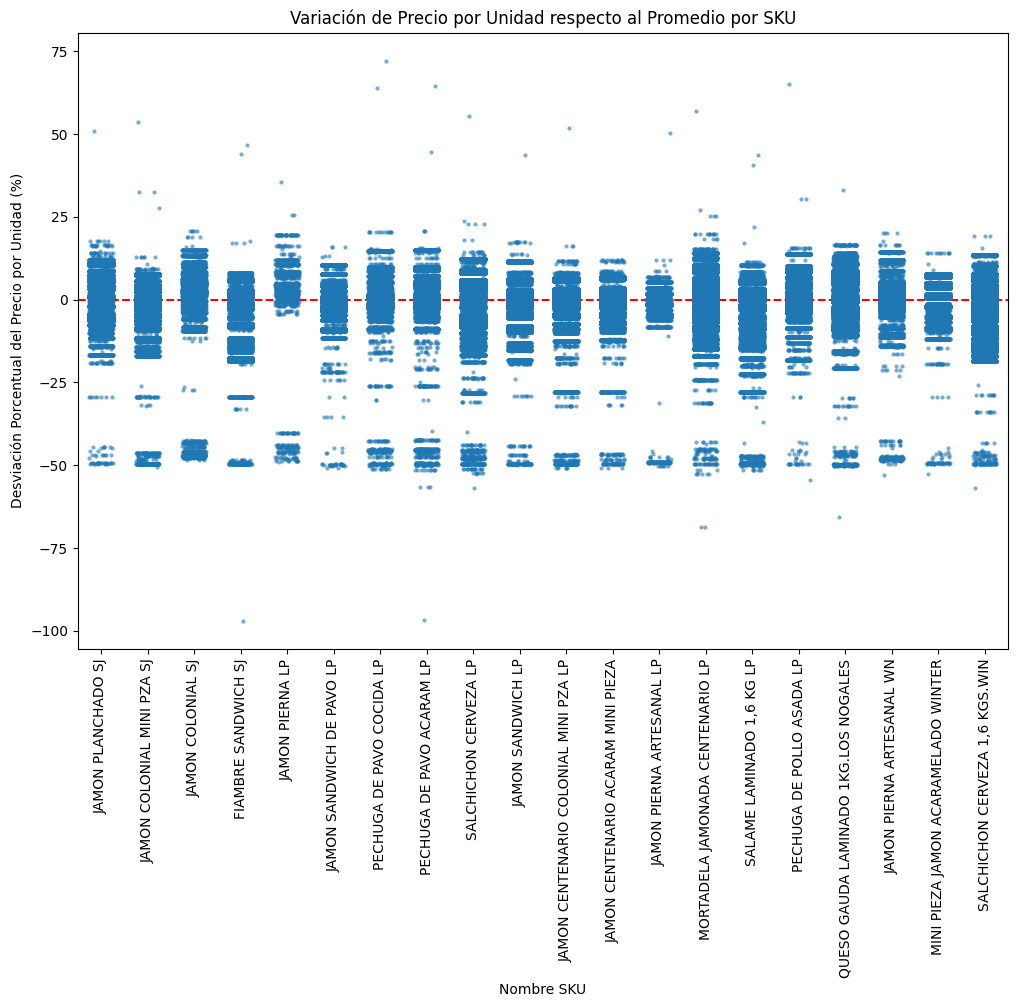

In [25]:
# Graficar  variación de precio unitario c/r a precio promedio (como porcentaje) agrupando por SKU
# Tomamos desviacion para cada sku
datos_grafico = ventas[["cod_sku", "nombre_sku", "cod_canal_comercial", "desviacion_porcentual_precio_por_unidad"]].copy()

# Filtrar ventas con desviación porcentual extrema (ej. > 100% o < -100%) para evitar distorsionar el gráfico
datos_grafico = datos_grafico[(datos_grafico["desviacion_porcentual_precio_por_unidad"] < 100) & (datos_grafico["desviacion_porcentual_precio_por_unidad"] > -100)]

# Filtrar y dejar sólo 20 SKUs con más importancia (desviacion_por_unidad_por_ingreso) para visualizar
skus_mas_importantes = tabla_sku.sort_values("desviacion_por_unidad_por_ingreso", ascending=False).head(20)["cod_sku"]
print("SKUs más importantes:", skus_mas_importantes.values)
datos_grafico = datos_grafico[datos_grafico["cod_sku"].isin(skus_mas_importantes)]
datos_grafico["cod_sku_cat"] = datos_grafico["cod_sku"].astype(str)
orden_skus = sorted(datos_grafico["cod_sku_cat"].unique())
nombre_por_cat = datos_grafico[["cod_sku_cat", "nombre_sku"]].drop_duplicates(subset=["cod_sku_cat"]).set_index("cod_sku_cat")["nombre_sku"]
etiquetas_x = [nombre_por_cat.get(cod, cod) for cod in orden_skus]

plt.figure(figsize=(12, 8))
ax = sns.stripplot(x="cod_sku_cat", y="desviacion_porcentual_precio_por_unidad", data=datos_grafico, order=orden_skus, jitter=0.25, alpha=0.6, size=3)
plt.axhline(0, color="red", linestyle="--")                     # Agregar linea punteada en y=0 para referencia
plt.title("Variación de Precio por Unidad respecto al Promedio por SKU")
plt.xlabel("Nombre SKU")
plt.ylabel("Desviación Porcentual del Precio por Unidad (%)")
plt.xticks(ticks=range(len(orden_skus)), labels=etiquetas_x, rotation=90)
plt.show()

In [26]:
canales = datos_grafico["cod_canal_comercial"].unique()
print("Canales comerciales presentes en el gráfico:", canales)

Canales comerciales presentes en el gráfico: <StringArray>
['CB', 'HR', 'MY']
Length: 3, dtype: str


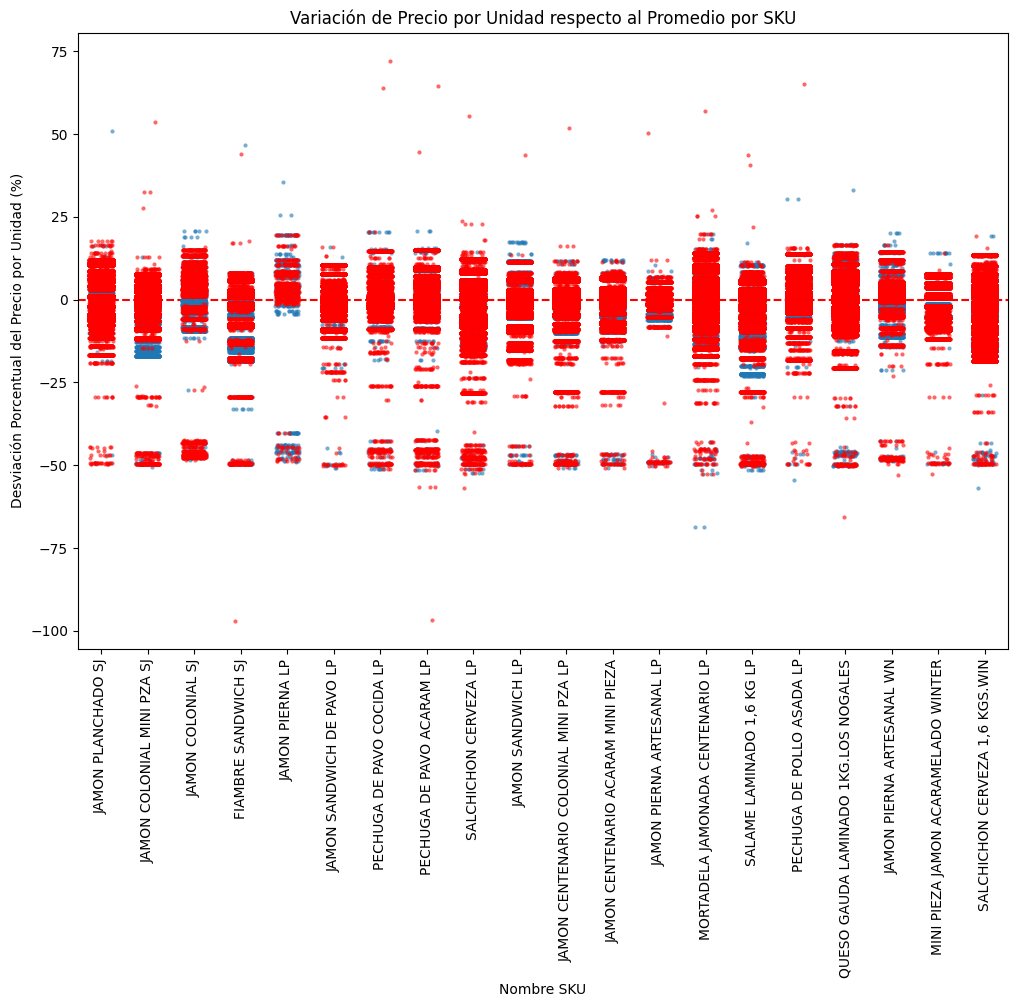

In [27]:
# Mismo gráfico pero con destacar algunos canales con color rojo
canales_destacados = ["CB"]
datos_destacados = datos_grafico[datos_grafico["cod_canal_comercial"].isin(canales_destacados) & datos_grafico["cod_sku"].isin(skus_mas_importantes)]
datos_no_destacados = datos_grafico[~datos_grafico["cod_canal_comercial"].isin(canales_destacados) & datos_grafico["cod_sku"].isin(skus_mas_importantes)]

plt.figure(figsize=(12, 8))
# Graficar todos los puntos en gris
ax = sns.stripplot(x="cod_sku_cat", y="desviacion_porcentual_precio_por_unidad", data=datos_no_destacados, order=orden_skus, jitter=0.25, alpha=0.6, size=3)
# Graficar los puntos destacados en rojo
sns.stripplot(x="cod_sku_cat", y="desviacion_porcentual_precio_por_unidad", data=datos_destacados, order=orden_skus, jitter=0.25, alpha=0.6, size=3, color="red")
plt.axhline(0, color="red", linestyle="--")                     # Agregar linea punteada en y=0 para referencia
plt.title("Variación de Precio por Unidad respecto al Promedio por SKU")
plt.xlabel("Nombre SKU")
plt.ylabel("Desviación Porcentual del Precio por Unidad (%)")
plt.xticks(ticks=range(len(orden_skus)), labels=etiquetas_x, rotation=90)
plt.show()

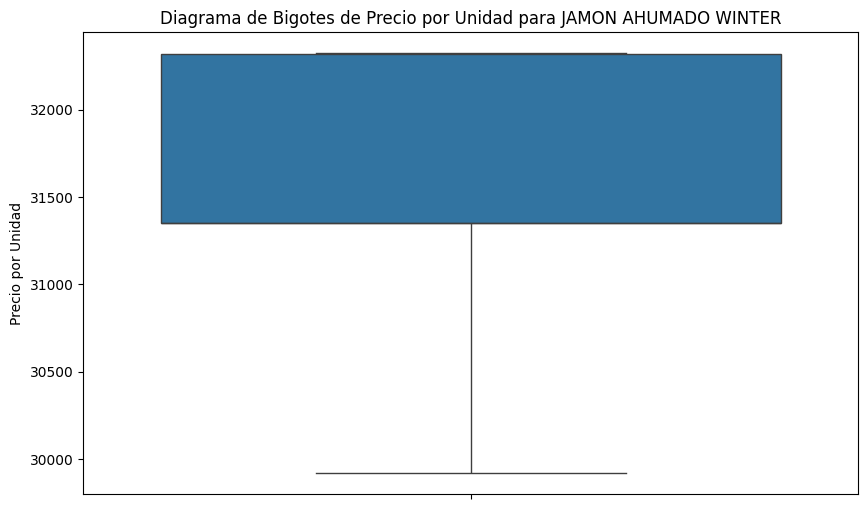

In [28]:
# Diagrama de bigotes de precio por unidad para un SKU dado
# Sacando datos outliers para visualizar mejor
SKU_EJEMPLO = 8630  # Reemplazar con un SKU real

nombre_producto = maestro[maestro["cod_sku"] == SKU_EJEMPLO]["texto_breve_material"].values[0]

datos_sku = ventas[ventas["cod_sku"] == SKU_EJEMPLO]
plt.figure(figsize=(10, 6))
sns.boxplot(y=datos_sku["precio_por_unidad"], showfliers=False)
plt.title(f"Diagrama de Bigotes de Precio por Unidad para {nombre_producto}")
plt.ylabel("Precio por Unidad")
plt.show()

## 2.2 Descuento con respecto a Precio Lista

In [29]:
# Agregar a ventas una columna que indique el porcentaje de descuento c/r al precio lista
ventas["descuento_por_unidad"] = (1 - ventas["precio_por_unidad"] / ventas["precio_lista_por_unidad"]) * 100
ventas["descuento"] = (1 - ventas["precio_real"] / ventas["precio_lista"]) * 100
ventas.head()

,cod_cliente,cod_canal_comercial,cod_consolidado,fecha_factura,cod_sku,nombre_sku,monto_real,kilo_real,precio_real,precio_lista,...,peso_variable,cantidad_unidades,cantidad_unidades_entera,inconsistencia,precio_por_unidad,precio_lista_por_unidad,precio_promedio_por_unidad,desviacion_porcentual_precio_por_unidad,descuento_por_unidad,descuento
0,1145633,CB,32,2025-01-02,3034,SALAME 10x100 GR LP,43440,4.0,10860.000000,11538.0,...,False,40.0,True,False,1086.000000,1153.800,1095.574514,-0.873926,5.876235,5.876235
1,1145633,CB,32,2025-01-02,3049,MORTADELA JAMONADA LP 150 G.,17919,3.3,5430.000000,5656.0,...,False,22.0,True,False,814.500000,848.400,755.307571,7.836864,3.995757,3.995757
2,1145633,CB,32,2025-01-02,3080,PATE TEEWURST 16x125 GR LP,23888,4.0,5972.000000,6516.0,...,False,32.0,True,False,746.500000,814.500,761.358632,-1.951594,8.348680,8.348680
3,1145633,CB,32,2025-01-02,3108,JAMON PIERNA CP 8x250 GR LP,48869,6.0,8144.833333,8145.0,...,False,24.0,True,False,2036.208333,2036.250,1896.325798,7.376503,0.002046,0.002046
4,1145633,CB,32,2025-01-02,3148,PASTA POLLO PIMENTON 8x125 GR LP,4887,1.0,4887.000000,4887.0,...,False,8.0,True,False,610.875000,610.875,576.999075,5.871054,0.000000,0.000000


In [30]:
# Comparar descuento_por_unidad con descuento real
ventas["diferencia_descuento"] = ventas["descuento_por_unidad"] - ventas["descuento"]

# Contar cuantas filas tienen diferencia significativa entre descuento_por_unidad y descuento real (ej. > 5 puntos porcentuales)
diferencia_significativa = ventas[np.abs(ventas["diferencia_descuento"]) > 1]
print("Número de filas con diferencia significativa entre descuento_por_unidad y descuento real:", diferencia_significativa.shape[0])

# Ver filas con diferencia significativa
diferencia_significativa["cod_sku"].value_counts()

Número de filas con diferencia significativa entre descuento_por_unidad y descuento real: 59


cod_sku
8508    13
3456     8
3032     7
6770     5
8043     3
3879     2
3313     2
2272     2
421      2
1020     2
738      1
8080     1
6772     1
8284     1
8454     1
1032     1
6777     1
6776     1
1404     1
3922     1
3945     1
1433     1
916      1
Name: count, dtype: int64

In [31]:
ventas = ventas[ventas["precio_lista"] > 0]
print(ventas.shape)
print(ventas[ventas["descuento"] < 0].shape)
print(ventas[ventas["descuento"] < -0.1].shape)
ventas[ventas["descuento"] < 0].sort_values("descuento").head()

(10364344, 24)
(2200167, 24)
(12838, 24)


,cod_cliente,cod_canal_comercial,cod_consolidado,fecha_factura,cod_sku,nombre_sku,monto_real,kilo_real,precio_real,precio_lista,...,cantidad_unidades,cantidad_unidades_entera,inconsistencia,precio_por_unidad,precio_lista_por_unidad,precio_promedio_por_unidad,desviacion_porcentual_precio_por_unidad,descuento_por_unidad,descuento,diferencia_descuento
3107461,1137320,MY,57,2025-05-15,1228,JAMON PLANCHADO SJ,30608,0.6,51013.333333,5430.0,...,0.181818,False,False,168344.000,17919.000,17749.702863,848.432778,-839.472069,-839.472069,0.000000e+00
5142728,1196805,CB,32,2025-08-13,421,PATE TERNERA 8x125 GRS.SJ,9823,1.0,9823.000000,3878.0,...,8.000000,True,False,1227.875,484.750,482.635343,154.410502,-153.300670,-153.300670,0.000000e+00
1912187,1166369,CB,54,2025-03-21,210,FIAMBRE SANDWICH SJ,7384,1.0,7384.000000,3620.0,...,0.285878,False,False,25829.232,12662.760,12579.859667,105.322100,-103.977901,-103.977901,0.000000e+00
7590817,1236913,CB,32,2025-12-02,3899,HAMBURGUESA GRILL TASTE LP 20X185 G.,38483,3.7,10400.810811,6289.0,...,20.000000,True,False,1924.150,1163.465,1022.670145,88.149621,-65.380996,-65.380996,-1.421085e-14
7746499,1236913,CB,32,2025-12-09,3899,HAMBURGUESA GRILL TASTE LP 20X185 G.,38482,3.7,10400.540541,6289.0,...,20.000000,True,False,1924.100,1163.465,1022.670145,88.144732,-65.376698,-65.376698,0.000000e+00


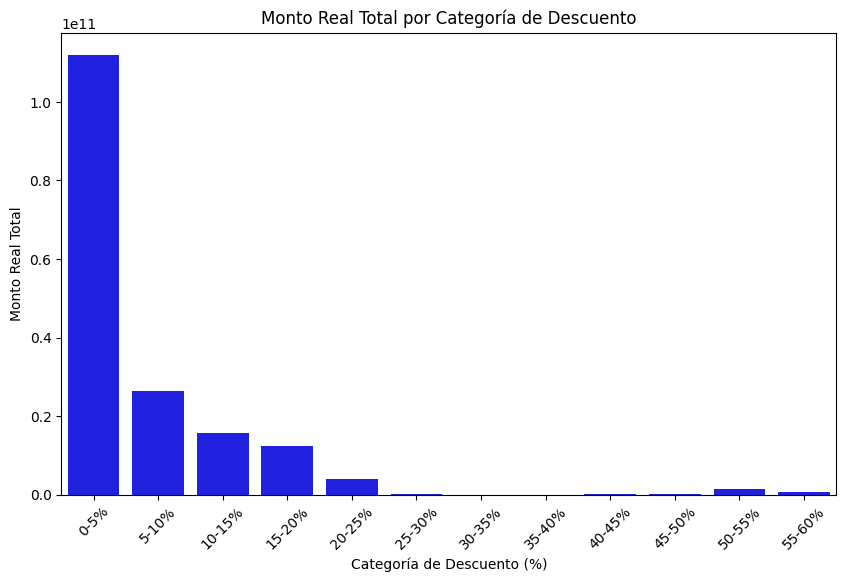

In [32]:
# Gráfico de columnas, una columna por cada 10% de descuento (0-10%, 10-20%, ..., 90-100%)
# En el eje x las categorías de descuento (0-10%, 10-20%, ..., 90-100%)
# En el eje y la cantidad de ventas en cada categoría, tomado como el monto real total de las ventas en cada categoría
largo_bins = 5
descuento_max = 60
bins = np.arange(0, descuento_max + largo_bins, largo_bins)
labels = [f"{i}-{i+largo_bins}%" for i in range(0, descuento_max, largo_bins)]

ventas["categoria_descuento"] = pd.cut(ventas["descuento"], bins=bins, right=False, labels=labels)
ventas_categoria = ventas.groupby("categoria_descuento")["monto_real"].sum().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(x="categoria_descuento", y="monto_real", data=ventas_categoria, color="blue")
plt.title("Monto Real Total por Categoría de Descuento")
plt.xlabel("Categoría de Descuento (%)")
plt.xticks(rotation=45)
plt.ylabel("Monto Real Total")
plt.show()

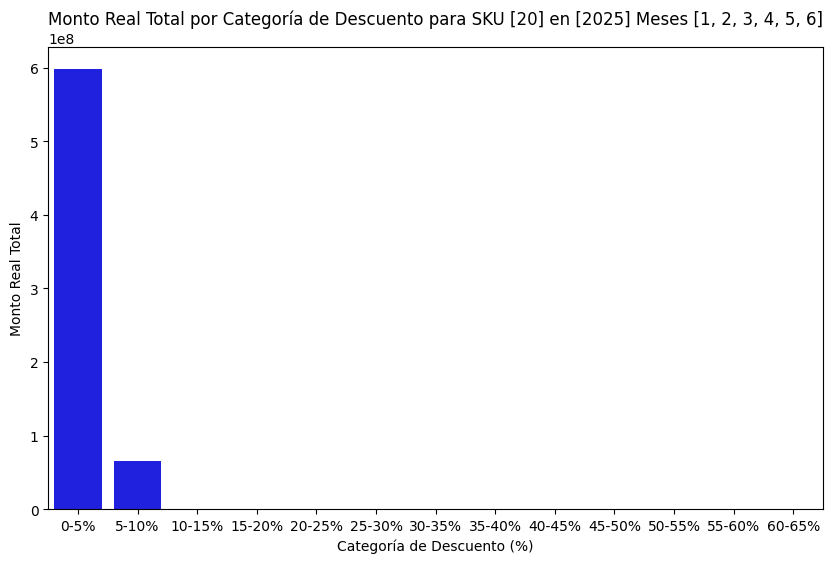

In [33]:
# Mismo gráfico anterior pero con posibilidad de filtrar año-mes de Fecha Factura y SKU
Años = [2025]
Meses = range(1, 7)
SKUs = [20]

ventas_filtradas = ventas[ventas["año_factura"].isin(Años) & ventas["mes_factura"].isin(Meses) & ventas["cod_sku"].isin(SKUs)]
ventas_filtradas["categoria_descuento"] = pd.cut(ventas_filtradas["descuento"], bins=np.arange(0, 70, 5), right=False, labels=[f"{i}-{i+5}%" for i in range(0, 65, 5)])
ventas_categoria_filtrada = ventas_filtradas.groupby("categoria_descuento")["monto_real"].sum().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(x="categoria_descuento", y="monto_real", data=ventas_categoria_filtrada, color="blue")
plt.title(f"Monto Real Total por Categoría de Descuento para SKU {SKUs} en {Años} Meses {list(Meses)}")
plt.xlabel("Categoría de Descuento (%)")
plt.ylabel("Monto Real Total")
plt.show()

# 3. Elasticidad

# 3.1. Elasticidad por SKU

# 3.2 Elasticidad por SKU-zona